In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for charts
sns.set_theme(style="whitegrid")

In [7]:
# === CELL 3: DATA STRUCTURE & QUALITY AUDIT ===

print("📏 1. DATASET DIMENSIONS")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}\n")

print("🔍 2. DATA TYPES & NON-NULL COUNTS")
df.info()

print("\n⚠️ 3. MISSING VALUES PER COLUMN")
missing_vals = df.isnull().sum()
missing_summary = missing_vals[missing_vals > 0]
if len(missing_summary) > 0:
    print(missing_summary)
else:
    print("✅ No missing values detected in the dataset.")

print(f"\n👯 4. DUPLICATE ROWS: {df.duplicated().sum()}")

print("\n📈 5. NUMERICAL SUMMARY STATISTICS")
display(df.describe().T)

# Summarize categorical features if any exist
cat_cols = df.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    print("\n📋 6. CATEGORICAL SUMMARY STATISTICS")
    display(df.describe(include=['object', 'category']).T)

📏 1. DATASET DIMENSIONS
Total Rows: 504 | Total Columns: 10

🔍 2. DATA TYPES & NON-NULL COUNTS
<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   employee_id        504 non-null    int64  
 1   age                504 non-null    int64  
 2   department         504 non-null    str    
 3   gender             504 non-null    str    
 4   education          494 non-null    str    
 5   years_experience   504 non-null    int64  
 6   monthly_salary     484 non-null    float64
 7   performance_score  489 non-null    float64
 8   join_date          504 non-null    str    
 9   attrition          504 non-null    str    
dtypes: float64(2), int64(3), str(5)
memory usage: 39.5 KB

⚠️ 3. MISSING VALUES PER COLUMN
education            10
monthly_salary       20
performance_score    15
dtype: int64

👯 4. DUPLICATE ROWS: 4

📈 5. NUMERICAL SUMMARY STATISTICS

,count,mean,std,min,25%,50%,75%,max
employee_id,504.0,1250.023810,144.494620,1001.0,1124.7500,1250.500,1374.2500,1500.00
age,504.0,41.273810,12.203397,21.0,31.7500,42.000,52.0000,101.00
years_experience,504.0,17.126984,9.920546,0.0,9.0000,18.000,25.0000,34.00
monthly_salary,484.0,73300.444928,31563.978685,18000.0,58209.5625,71109.415,85503.9375,465799.14
performance_score,489.0,70.273006,11.790503,38.4,62.1000,70.200,78.2000,107.30



📋 6. CATEGORICAL SUMMARY STATISTICS


C:\Users\SRAVANI\AppData\Local\Temp\ipykernel_6160\3359529988.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns
C:\Users\SRAVANI\AppData\Local\Temp\ipykernel_6160\3359529988.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org

,count,unique,top,freq
department,504,5,Sales,156
gender,504,2,Male,270
education,494,4,Bachelors,213
join_date,504,500,2012-08-23,2
attrition,504,2,No,416


C:\Users\SRAVANI\AppData\Local\Temp\ipykernel_6160\1980084551.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


<Figure size 1400x800 with 0 Axes>

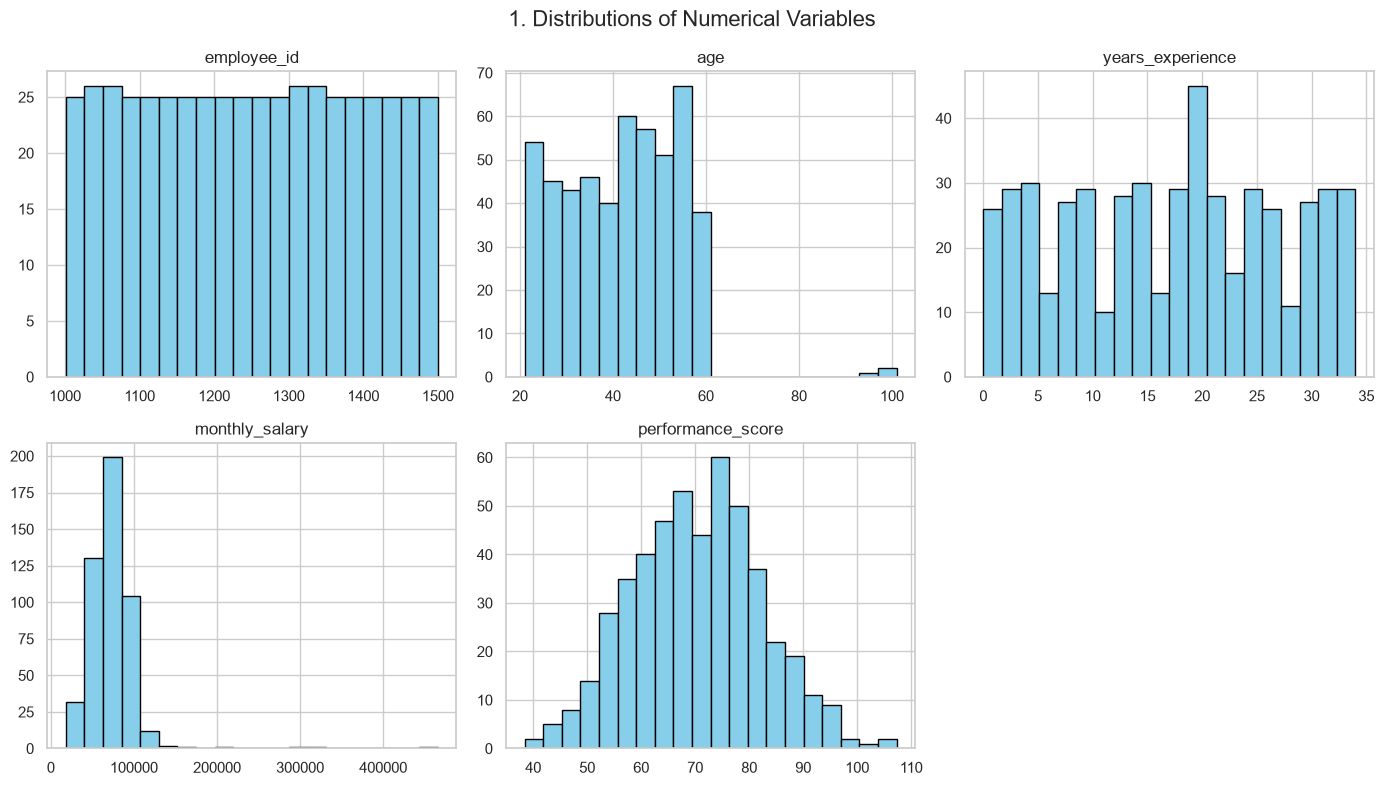

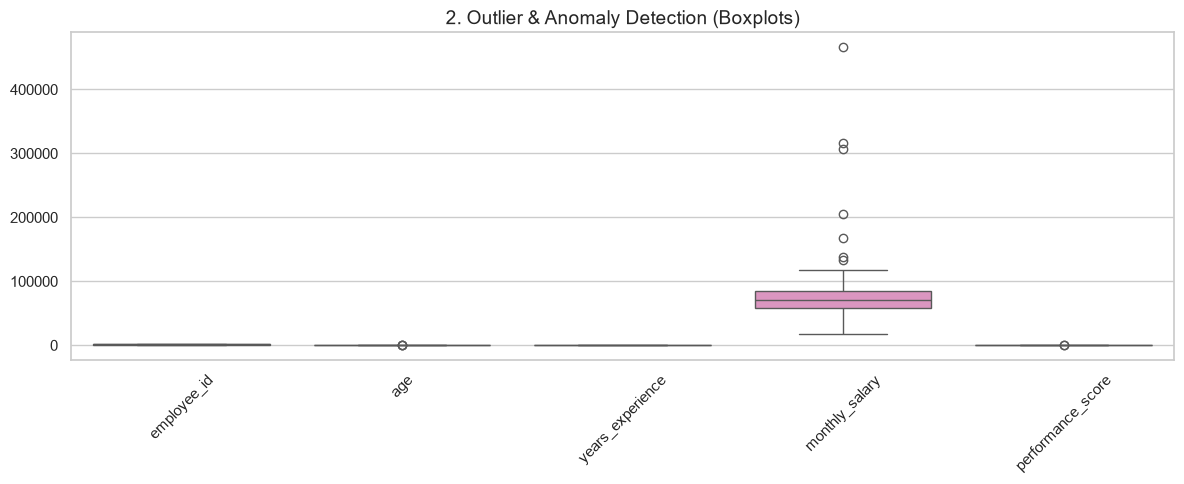

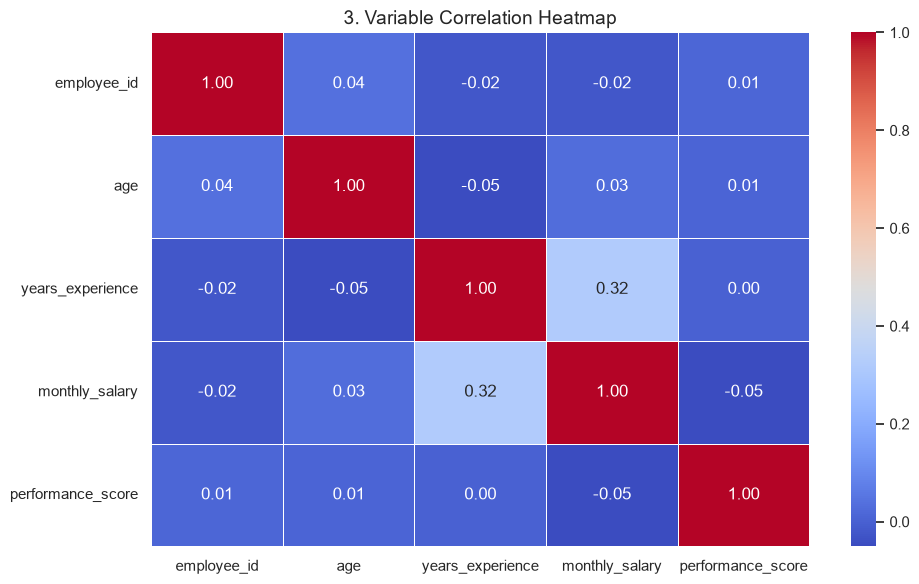

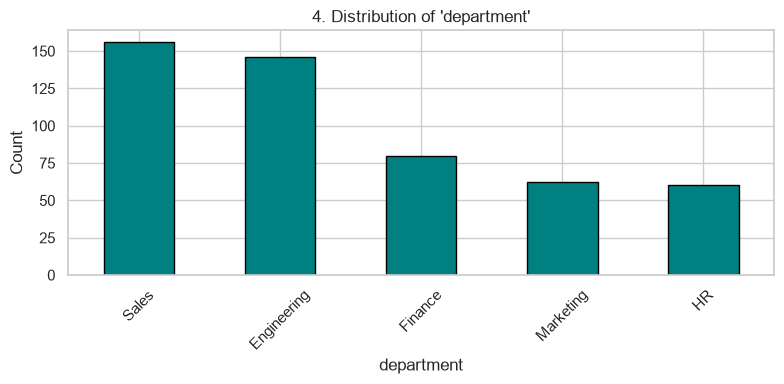

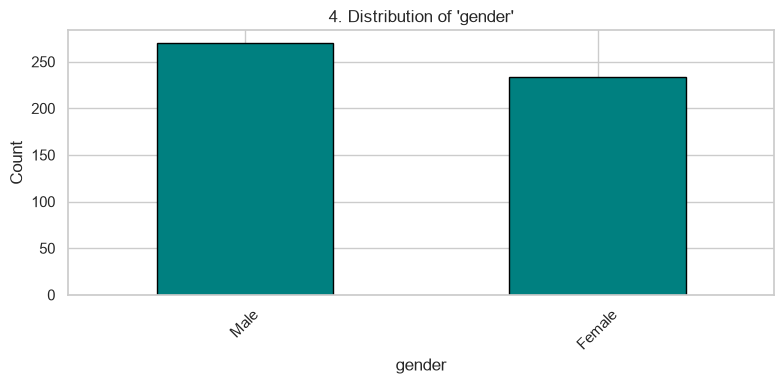

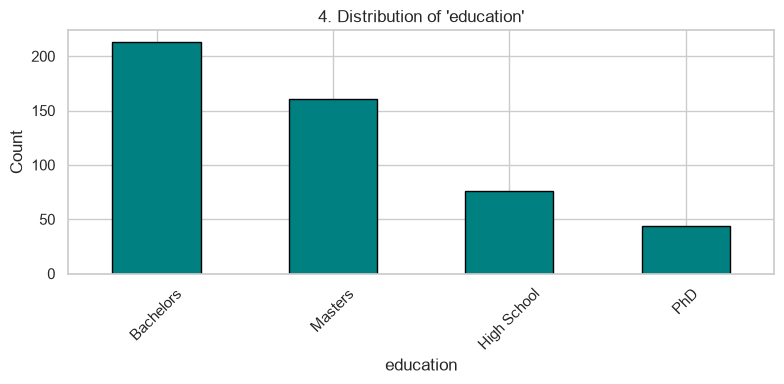

In [8]:
# === CELL 4: TRENDS, PATTERNS & ANOMALIES VISUALIZATIONS ===
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numeric and categorical columns
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# 1. Distribution of Numerical Features
if len(num_cols) > 0:
    plt.figure(figsize=(14, 8))
    df[num_cols].hist(bins=20, figsize=(14, 8), color='skyblue', edgecolor='black', layout=(-1, 3))
    plt.suptitle("1. Distributions of Numerical Variables", fontsize=16)
    plt.tight_layout()
    plt.show()

    # 2. Anomaly & Outlier Detection (Boxplots)
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=df[num_cols], palette="Set2")
    plt.title("2. Outlier & Anomaly Detection (Boxplots)", fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 3. Correlation Heatmap
    if len(num_cols) > 1:
        plt.figure(figsize=(10, 6))
        sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
        plt.title("3. Variable Correlation Heatmap", fontsize=14)
        plt.tight_layout()
        plt.show()

# 4. Top Categorical Feature Distributions
if len(cat_cols) > 0:
    for col in cat_cols[:3]:  # Plots top 3 categorical features
        plt.figure(figsize=(8, 4))
        df[col].value_counts().head(10).plot(kind='bar', color='teal', edgecolor='black')
        plt.title(f"4. Distribution of '{col}'", fontsize=12)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [5]:
import os
import pandas as pd

# Define possible relative locations for 'dataset.csv'
possible_paths = [
    'dataset.csv',          # Current folder
    '../dataset.csv',       # Parent folder (one level up)
    '../../dataset.csv'     # Two levels up
]

csv_path = None
for path in possible_paths:
    if os.path.exists(path):
        csv_path = path
        break

# If still not found, search the entire parent workspace
if not csv_path:
    parent_dir = os.path.abspath('..')
    for root, dirs, files in os.walk(parent_dir):
        if 'dataset.csv' in files:
            csv_path = os.path.join(root, 'dataset.csv')
            break

# Load dataset
if csv_path:
    df = pd.read_csv(csv_path)
    print(f"✅ Successfully loaded dataset from: {csv_path}\n")
    display(df.head())
else:
    print("❌ Could not locate 'dataset.csv'. Please check file location.")
    

✅ Successfully loaded dataset from: ../dataset.csv



,employee_id,age,department,gender,education,years_experience,monthly_salary,performance_score,join_date,attrition
0,1001,59,Sales,Female,Masters,29,61976.92,67.3,2012-01-01,No
1,1002,49,Engineering,Male,Bachelors,13,74409.53,87.9,2012-01-06,No
2,1003,35,Sales,Female,Masters,5,56131.40,50.8,2012-01-11,No
3,1004,28,Engineering,Female,Masters,2,74543.14,60.1,2012-01-16,No
4,1005,41,Engineering,Male,PhD,15,89872.95,NaN,2012-01-21,No
